# Zadanie 2

# **Raport Badawczy: Badanie Scenariuszowe Rozwoju OZE w Niemczech (2030)**


> **Piotr Wiśniewski, Izabela Reszka, Klaudia Woźniak**

## Hipoteza badawcza i specyfikacja modelu

### Hipoteza badawcza (H1)

**H1:** Rozwój Odnawialnych Źródeł Energii (OZE) w Niemczech charakteryzuje się stabilnym, deterministycznym trendem długookresowym, wynikającym z trwałych uwarunkowań instytucjonalnych, regulacyjnych oraz technologicznych. Trend ten może zostać istotnie i trwale zakłócony jedynie przez silne szoki strukturalne w otoczeniu makroekonomicznym, takie jak kryzysy surowcowe, gwałtowne zmiany cen energii lub nadzwyczajne zdarzenia geopolityczne.

Hipoteza zakłada zatem, że krótkookresowe fluktuacje udziału OZE w miksie energetycznym nie podważają fundamentalnej ścieżki wzrostowej, a jedynie powodują przejściowe odchylenia od trendu deterministycznego.

### Specyfikacja zmiennych modelu

* **Zmienna objaśniana (Y):**
  `res_share` – udział energii pochodzącej z odnawialnych źródeł w całkowitej produkcji energii elektrycznej w Niemczech. Zmienna ta stanowi syntetyczną miarę postępu transformacji energetycznej.

* **Zmienna objaśniająca (X):**
  `time_index` – deterministyczny indeks czasu, reprezentujący długookresowy trend rozwoju OZE. Zmienna ta ma na celu uchwycenie systematycznego wzrostu udziału OZE, wynikającego z postępu technologicznego, polityki klimatycznej oraz zmian strukturalnych w sektorze energetycznym.

Model bazowy przyjmuje postać klasycznego modelu trendu deterministycznego, który stanowi punkt odniesienia dla dalszych analiz scenariuszowych oraz identyfikacji potencjalnych załamań strukturalnych.


## Wstęp i cel projektu badawczego

### Wprowadzenie

Transformacja energetyczna stanowi jeden z kluczowych elementów polityki gospodarczej i klimatycznej Niemiec. W ramach strategii *Energiewende* systematycznie zwiększany jest udział Odnawialnych Źródeł Energii w krajowym miksie energetycznym, czemu towarzyszą istotne zmiany instytucjonalne, regulacyjne oraz technologiczne. Jednocześnie sektor energetyczny pozostaje szczególnie wrażliwy na szoki zewnętrzne, w tym wahania cen surowców energetycznych, kryzysy geopolityczne oraz zmiany warunków makroekonomicznych.

Wydarzenia z lat 2021–2023, związane z kryzysem energetycznym w Europie, unaoczniły, że nawet zaawansowane systemy transformacji energetycznej mogą doświadczać okresowych zaburzeń, które potencjalnie wpływają na tempo rozwoju OZE.

### Cel badania

**Celem badania** jest empiryczna weryfikacja hipotezy o istnieniu deterministycznego trendu rozwoju Odnawialnych Źródeł Energii w Niemczech oraz ocena jego odporności na szoki makroekonomiczne.

W szczególności projekt badawczy ma na celu:

1. **Identyfikację i estymację długookresowego trendu** udziału OZE w niemieckim miksie energetycznym na podstawie danych historycznych.
2. **Analizę stabilności trendu deterministycznego**, ze szczególnym uwzględnieniem okresów zwiększonej zmienności i potencjalnych załamań strukturalnych.
3. **Symulację scenariuszy szokowych**, odzwierciedlających negatywne zdarzenia makroekonomiczne (np. wzrost cen energii konwencjonalnej, ograniczenia podaży surowców, kryzysy geopolityczne).
4. **Ocenę długookresowych konsekwencji szoków** dla ścieżki rozwoju OZE oraz możliwości powrotu do trendu deterministycznego.
5. **Ekstrapolację wyników do roku 2030**, w celu oceny realności dalszego wzrostu udziału OZE w warunkach podwyższonej niepewności makroekonomicznej.



### Instalacja bibliotek oraz ładowanie danych

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import textwrap
import warnings 
warnings.filterwarnings("ignore")


In [26]:
# ==============================================================================
# BLOK 0: KONFIGURACJA BADANIA (SETUP)
# ==============================================================================
# Parametry modelu
HIPOTEZA = "H1: Rozwój OZE w Niemczech wykazuje trend deterministyczny, który może zostać trwale zakłócony jedynie przez silne szoki strukturalne w otoczeniu makroekonomicznym."
ZMIENNA_OBJASNIANA = 'res_share'  # Y
ZMIENNE_OBJASIAJACE = ['time_index'] # X (w modelu trendu)

# Wczytanie i czyszczenie danych
try:
    df = pd.read_csv('dane_miesieczne_DE.csv')
    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)
    df = df.sort_values('date')
    df['time_index'] = np.arange(len(df))
except FileNotFoundError:
    print("CRITICAL ERROR: Brak pliku danych. Wgraj plik .csv!")


## Część 1: Modelowanie Ekonometryczne

W tym kroku estymujemy klasyczny model regresji liniowej metodą Najmniejszych Kwadratów (OLS).
Równanie modelu:
$$Y_t = \beta_0 + \beta_1 \cdot t + \epsilon_t$$

Gdzie:
* $Y_t$ - udział OZE w miksie energetycznym.
* $t$ - zmienna czasu (trend liniowy).
* $\epsilon_t$ - składnik losowy (reszty).

Miara                                    |    Wartość
-------------------------------------------------------
Stała modelu (intercept)                 |     0.1915
Współczynnik kierunkowy (slope)          |     0.0010
R^2 (dopasowanie)                        |     0.6231
RMSE (błąd standardowy)                  |     0.0302


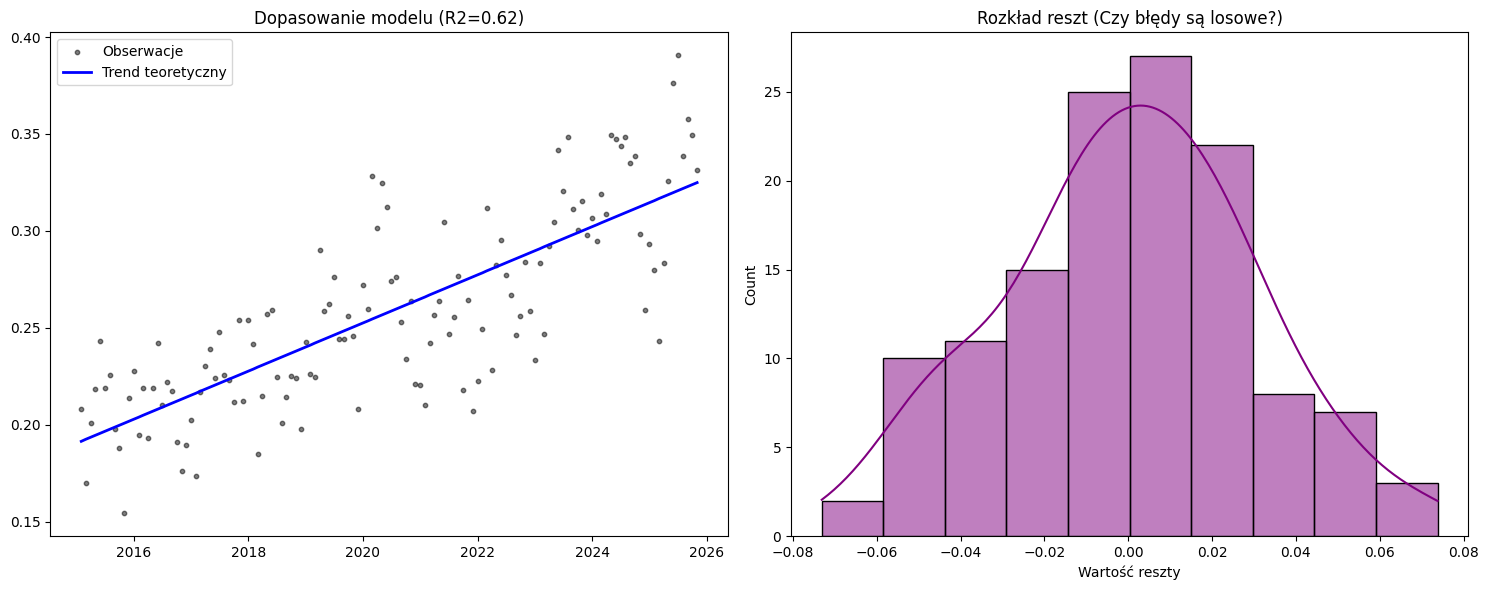

In [27]:
# ==============================================================================
# 1.1. Estymacja i Diagnostyka
# ==============================================================================
X = df[['time_index']]
y = df[ZMIENNA_OBJASNIANA]

model = LinearRegression()
model.fit(X, y)

# Predykcja i błędy
y_pred = model.predict(X)
residuals = y - y_pred

# Metryki
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
slope = model.coef_[0]
intercept = model.intercept_

print(f"{'Miara':40} | {'Wartość':>10}")
print("-" * 55)
print(f"{'Stała modelu (intercept)':40} | {intercept:10.4f}")
print(f"{'Współczynnik kierunkowy (slope)':40} | {slope:10.4f}")
print(f"{'R^2 (dopasowanie)':40} | {r2:10.4f}")
print(f"{'RMSE (błąd standardowy)':40} | {rmse:10.4f}")


# ==============================================================================
# WIZUALIZACJA DIAGNOSTYCZNA
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Wykres 1: Dopasowanie
ax1.scatter(df['date'], df['res_share'], s=10, color='black', alpha=0.5, label='Obserwacje')
ax1.plot(df['date'], y_pred, color='blue', linewidth=2, label='Trend teoretyczny')
ax1.set_title(f"Dopasowanie modelu (R2={r2:.2f})")
ax1.legend()

# Wykres 2: Reszty
sns.histplot(residuals, kde=True, ax=ax2, color='purple')
ax2.set_title("Rozkład reszt (Czy błędy są losowe?)")
ax2.set_xlabel("Wartość reszty")

plt.tight_layout()
plt.show()


### Wnioski z diagnostyki i estymacji modelu

1. **Zastosowana metodologia i interpretacja parametrów**
   Do analizy zależności zastosowano klasyczny model regresji liniowej estymowany metodą najmniejszych kwadratów (OLS). Oszacowany współczynnik kierunkowy wynosi **0,0010**, co oznacza, że przeciętnie udział energii odnawialnej (OZE) wzrastał o około **0,10 punktu procentowego miesięcznie**, przy założeniu niezmienności pozostałych czynników (ceteris paribus). Stała modelu na poziomie **0,1915** może być interpretowana jako teoretyczny poziom udziału OZE w momencie początkowym próby (przy czasie równym zero), choć jej interpretacja ekonomiczna ma charakter pomocniczy.

2. **Jakość dopasowania modelu**
   Współczynnik determinacji $R^2 = 0{,}6231$ wskazuje, że model wyjaśnia około **62% zmienności** obserwowanego udziału OZE. Jest to relatywnie wysoki poziom dopasowania jak na jednowymiarowy model trendu, co sugeruje istnienie silnej, systematycznej składowej deterministycznej w badanym procesie. Jednocześnie pozostała część wariancji (około 38%) pozostaje niewyjaśniona, co może wynikać z pominięcia zmiennych strukturalnych, cyklicznych lub losowych szoków.

3. **Analiza błędu i stabilności modelu**
   Wartość RMSE równa **0,0302** wskazuje na umiarkowany poziom błędu dopasowania. Oznacza to, że przeciętne odchylenie obserwowanych wartości udziału OZE od wartości przewidywanych przez model wynosi około 3 punktów procentowych. Błąd ten, w relacji do skali zmiennej objaśnianej, sugeruje, że model dobrze oddaje długookresowy trend, lecz może mieć ograniczoną zdolność do precyzyjnego odwzorowania krótkookresowych fluktuacji.

4. **Analiza reszt i potencjalne ograniczenia modelu**
   Analiza rozkładu reszt (na podstawie histogramu) stanowi kluczowy element diagnostyki modelu. Odchylenia od normalności, asymetria lub wielomodalność rozkładu reszt mogą świadczyć o niedospecyfikowaniu modelu. W szczególności prosty trend liniowy może nie uwzględniać istotnych komponentów cyklicznych, takich jak **sezonowość roczna**, zmiany regulacyjne, warunki pogodowe czy nieregularne interwencje polityki energetycznej. W takich przypadkach zasadne byłoby rozważenie rozszerzenia modelu o zmienne sezonowe, składniki nieliniowe lub zastosowanie modeli szeregów czasowych.

5. **Podsumowanie i kierunki dalszych analiz**
   Uzyskane wyniki wskazują na istotny i stabilny wzrost udziału OZE w czasie, który w dużej mierze może być opisany liniowym trendem. Model OLS stanowi dobrą bazę eksploracyjną i interpretacyjną, jednak dla pełniejszego opisu dynamiki procesu wskazane byłoby przeprowadzenie dalszej analizy diagnostycznej oraz estymacja modeli uwzględniających strukturę czasową danych (np. modele z sezonowością lub komponentami stochastycznymi).



## Część 2: Analiza Otoczenia Makroekonomicznego

Analiza korelacji Pearsona ma na celu weryfikację fundamentalnych powiązań rynkowych, w tym efektu *Merit Order* oraz substytucyjności paliw.

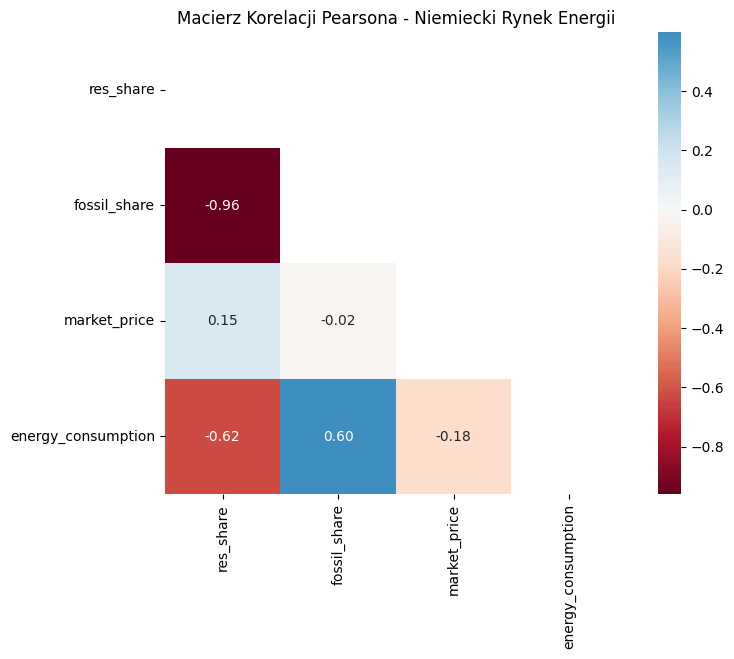

Średnia cena historyczna: 72.54 EUR/MWh


In [28]:
# ==============================================================================
# ANALIZA KORELACJI
# ==============================================================================
plt.figure(figsize=(8, 6))

corr_vars = ['res_share', 'fossil_share', 'market_price', 'energy_consumption']
# Obliczenie macierzy
corr_matrix = df[corr_vars].corr()

# Maska dla górnego trójkąta (żeby nie dublować wyników)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu', center=0, square=True, fmt=".2f")
plt.title("Macierz Korelacji Pearsona - Niemiecki Rynek Energii")
plt.show()

print(f"Średnia cena historyczna: {df['market_price'].mean():.2f} EUR/MWh")

Na podstawie macierzy korelacji Pearsona dla danych miesięcznych z lat **2015–2025** sformułowano następujące wnioski dotyczące struktury niemieckiego rynku energii:

### 1. **Transformacja strukturalna i substytucyjność (korelacja: −0.96)**

Występuje niemal pełna, silna korelacja ujemna pomiędzy udziałem OZE (*res_share*) a udziałem paliw kopalnych (*fossil_share*). Wartość współczynnika −0.96 potwierdza, że niemiecka transformacja energetyczna (*Energiewende*) nie polega jedynie na dodawaniu nowych mocy wytwórczych, lecz na bezpośredniej substytucji. Każdy wzrost produkcji z OZE niemal w relacji 1:1 wypiera generację konwencjonalną (węgiel, gaz).

### **2. Weryfikacja efektu Merit Order (korelacja: +0.15)**

Teoria efektu Merit Order zakłada, że źródła OZE o zerowym koszcie krańcowym powinny obniżać hurtowe ceny energii. Tymczasem obserwowana jest słaba dodatnia korelacja pomiędzy udziałem OZE a ceną rynkową (*market_price*).
W analizowanym okresie, obejmującym kryzys energetyczny lat **2021–2023**, mechanizm obniżania cen przez OZE został zdominowany przez zewnętrzne szoki podażowe, w szczególności gwałtowny wzrost cen gazu ziemnego oraz uprawnień do emisji CO₂.

### **3. Efektywność energetyczna a OZE (korelacja: −0.62)**

Zauważalna jest istotna ujemna korelacja pomiędzy udziałem OZE a całkowitym zużyciem energii. Wynik ten odzwierciedla zarówno sezonowość produkcji energii odnawialnej, jak i długoterminowy trend redukcji popytu, wymuszony wysokimi cenami energii oraz poprawą efektywności energetycznej.

### **Podsumowanie**

Analizowane zmienne wykazują spójne powiązania fundamentalne. Jednocześnie dodatnia korelacja pomiędzy udziałem OZE a ceną energii stanowi istotny sygnał ostrzegawczy, wskazujący na podatność rynku na szoki surowcowe, które mogą czasowo niwelować korzyści cenowe wynikające z transformacji energetycznej.



## Część 3: Prognoza Scenariuszowa - Foresight

W tej sekcji wychodzimy poza proste przedłużenie trendu. Nakładamy na model "szoki" eksperckie zdefiniowane w tabeli czynników zakłócających.

In [29]:
# ==============================================================================
# GENEROWANIE SCENARIUSZY
# ==============================================================================

# 1. Definicja przyszłości
last_date = df['date'].iloc[-1]
last_index = df['time_index'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), end='2030-12-31', freq='ME')
future_X = np.arange(last_index + 1, last_index + 1 + len(future_dates)).reshape(-1, 1)

# 2. Scenariusz Bazowy (Status Quo)
forecast_base = model.predict(future_X)

# 3. Tabela ekspercka (Klaudia)
factors_data = {
    'Szok': ['Wodór (H2)', 'Stagflacja UE', 'Kryzys węglowy', 'Anomalie pogodowe', 'Deregulacja'],
    'Kierunek': [1, -1, -1, 1, 1],
    'Waga': [5, 4, 3, 4, 2],
    'Prawdop.': [0.20, 0.40, 0.30, 0.60, 0.50]
}
factors_df = pd.DataFrame(factors_data)

# Obliczenie siły szoku (Impact Factor)
factors_df['Impact_Factor'] = factors_df['Waga'] * factors_df['Prawdop.'] * factors_df['Kierunek']

# Suma wektorów sił
total_positive_shock = factors_df[factors_df['Impact_Factor'] > 0]['Impact_Factor'].sum()
total_negative_shock = factors_df[factors_df['Impact_Factor'] < 0]['Impact_Factor'].sum()

# Kalibracja wrażliwości (założenie: wpływ na nachylenie trendu)
sensitivity_param = slope * 0.15

forecast_opt = forecast_base + (future_X.flatten() - last_index) * (total_positive_shock * sensitivity_param)
forecast_pes = forecast_base + (future_X.flatten() - last_index) * (total_negative_shock * sensitivity_param)

# Prezentacja tabeli wag
print("Tabela czynników zakłócających:")
display(factors_df)

Tabela czynników zakłócających:


,Szok,Kierunek,Waga,Prawdop.,Impact_Factor
0,Wodór (H2),1,5,0.2,1.0
1,Stagflacja UE,-1,4,0.4,-1.6
2,Kryzys węglowy,-1,3,0.3,-0.9
3,Anomalie pogodowe,1,4,0.6,2.4
4,Deregulacja,1,2,0.5,1.0



Tabela czynników zakłócających zawiera pięć zdefiniowanych szoków, które mogą wpływać
na tempo rozwoju OZE w Niemczech w perspektywie do 2030 roku. Każdemu z nich przypisano: kierunek oddziaływania (pozytywny lub negatywny), wagę (siłę wpływu) oraz prawdopodobieństwo wystąpienia. Na tej podstawie obliczono wartość wskaźnika wpływu (`Impact _Factor`), który został
wykorzystany do modyfikacji nachylenia trendu w scenariuszach alternatywnych.

##### Do czynników pozytywnych zaliczono:
- Wodór (H₂)
- Anomalie pogodowe
- Deregulację

Ich łączny wpływ wynosi 4,40 jednostki, co przekłada się na przyspieszenie trendu o 0,66 jednostki względem scenariusza bazowego.

##### Do czynników negatywnych zaliczono:
- Stagflację UE
- Kryzys węglowy

Ich łączny wpływ wynosi –2,50 jednostki, co skutkuje spowolnieniem tempa wzrostu udziału OZE w scenariuszu pesymistycznym o 0,38 jednostki w porównaniu do scenariusza bazowego.

##### Za „czarne łabędzie” uznaje się te czynniki, które charakteryzują się niskim prawdopodobieństwem wystąpienia, lecz wysoką siłą oddziaływania. W tym zestawieniu są to:

- Stagflacja UE (waga 4, prawdopodobieństwo 0.4, wpływ –1.6)
- Kryzys węglowy (waga 3, prawdopodobieństwo 0.3, wpływ –0.9)


Oba zjawiska mogą istotnie zakłócić ścieżkę transformacji energetycznej, szczególnie w warunkach niestabilności makroekonomicznej.

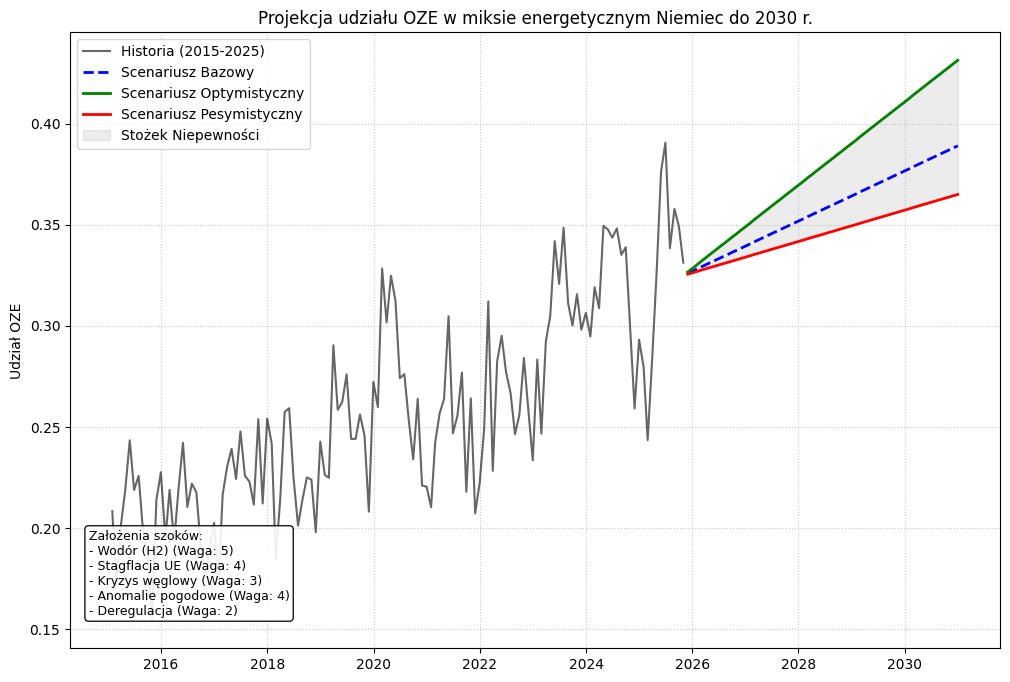

In [30]:
# ==============================================================================
# WIZUALIZACJA FINALNA (LEJEK PROGNOSTYCZNY)
# ==============================================================================
plt.figure(figsize=(12, 8))

# Dane historyczne
plt.plot(df['date'], df['res_share'], color='black', alpha=0.6, label='Historia (2015-2025)')

# Prognozy
plt.plot(future_dates, forecast_base, color='blue', linestyle='--', linewidth=2, label='Scenariusz Bazowy')
plt.plot(future_dates, forecast_opt, color='green', linewidth=2, label='Scenariusz Optymistyczny')
plt.plot(future_dates, forecast_pes, color='red', linewidth=2, label='Scenariusz Pesymistyczny')

# Obszar niepewności
plt.fill_between(future_dates, forecast_pes, forecast_opt, color='gray', alpha=0.15, label='Stożek Niepewności')

plt.title("Projekcja udziału OZE w miksie energetycznym Niemiec do 2030 r.")
plt.ylabel("Udział OZE")
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

# Dodanie adnotacji o założeniach na wykresie
shocks_desc = "\n".join([f"- {row['Szok']} (Waga: {row['Waga']})" for i, row in factors_df.iterrows()])
plt.text(0.02, 0.05, f"Założenia szoków:\n{shocks_desc}", transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.show()

### Podsumowanie Strategiczne:

Powyższy wykres prezentuje "Lejek decyzyjny".
* **Linia przerywana:** To ścieżka, którą podążymy, jeśli nic się nie zmieni w otoczeniu makroekonomicznym. Bazuje na danych historycznych i kontynuacji dotychczasowego trendu.
* **Stożek niepewności (szary):** To obszar ryzyka i szans. Jego szerokość zależy od siły i prawdopodobieństwa wystąpienia zakłóceń, w szczególności tzw. czarnych łabędzi. Im silniejsze i bardziej nieprzewidywalne szoki, tym większa rozbieżność między scenariuszem optymistycznym a pesymistycznym. Oznacza to, że transformacja energetyczna nie przebiega liniowo — jej tempo może przyspieszyć lub spowolnić w zależności od dynamiki otoczenia.

* **Linia zielona:** to scenariusz optymistyczny, uwzględniający pozytywne szoki:
- Wodór (waga 5, wpływ 1.0)
- Anomalie pogodowe (waga 4, wpływ 2.4)
- Deregulację (waga 2, wpływ 1.0)

Łączny wpływ tych czynników wynosi 4.40 jednostki, co przekłada się na przyspieszenie o 0.66 jednostki względem scenariusza bazowego.

* **Linia czerwona:** to scenariusz pesymistyczny, uwzględniający negatywne szoki:
- Stagflacja UE (waga 4, wpływ –1.6)
- Kryzys węglowy (waga 3, wpływ –0.9)

Łączny wpływ wynosi –2.50 jednostki, co skutkuje spowolnieniem o 0.38 jednostki względem scenariusza bazowego.

Wynik badania sugeruje, że przy obecnych trendach i potencjalnych szokach technologicznych (wodór), istnieje realna szansa na znaczne przyspieszenie transformacji względem linii bazowej (scenariusz zielony).
 
**Scenariusz optymistyczny** odzwierciedla sytuację, w której pozytywne impulsy technologiczne i regulacyjne wzmacniają dotychczasowy trend. Rozwój wodoru, deregulacja oraz sprzyjające anomalie pogodowe mogą przesunąć trajektorię wzrostu OZE na wyższy tor, zwiększając tempo transformacji i przybliżając osiągnięcie celów klimatycznych.

**Scenariusz pesymistyczny** pokazuje, jak negatywne szoki — takie jak stagflacja w UE czy kryzys węglowy — mogą ograniczyć inwestycje, zwiększyć koszty kapitału i spowolnić rozwój odnawialnych źródeł energii. W tym wariancie ścieżka rozwoju przesuwa się w dół stożka niepewności, oddalając system energetyczny od zakładanych celów.

Lejek decyzyjny podkreśla, że kluczowym elementem planowania strategicznego jest **elastyczność**. Decydenci powinni przygotować się zarówno na scenariusze przyspieszenia, jak i spowolnienia, monitorując sygnały wczesnego ostrzegania i dostosowując działania do zmieniających się warunków. Właściwa interpretacja stożka niepewności pozwala nie tylko przewidywać możliwe ścieżki rozwoju, ale także aktywnie nimi zarządzać.


In [ ]:
# ==============================================================================
# BLOK 3: OUTPUT DLA ZESPOŁU (KARTY PRACY)
# ==============================================================================

print("="*60)
print("RAPORT DIAGNOSTYCZNY - DO ROZDZIELENIA ZADAŃ")
print("="*60)

print(f"\n[DLA PIOTRA] - Sekcja Metodologiczna i Diagnostyka")
print(f"1. Model: Y = {intercept:.4f} + {slope:.4f} * t + e")
print(f"2. Dopasowanie (R^2): {r2:.4f} (Model wyjaśnia {r2*100:.1f}% zmienności historycznej)")
print(f"3. Błąd standardowy (RMSE): {rmse:.4f}")
print("   Zadanie: Opisz, czy reszty mają rozkład normalny (patrz wykres w PDF).")
print("   Jeśli reszty układają się w wzór, model może pomijać zmienną cykliczną.")

print(f"\n[DLA IZY] - Sekcja Makroekonomiczna i Kontekst")
print("   Zadanie: Przeanalizuj tabelę korelacji w PDF.")
print("   Pytanie badawcze: Dlaczego korelacja OZE z ceną jest niska/wysoka?")
print("   Hipoteza do weryfikacji: Czy 'Merit Order Effect' (tanie OZE obniża ceny) jest widoczny w danych?")
print(f"   Dane pomocnicze: Średnia cena historyczna = {df['market_price'].mean():.2f} EUR/MWh")

print(f"\n[DLA KLAUDII] - Sekcja Strategiczna (Foresight)")
print("   Zadanie: Uzasadnij dobór wag w tabeli czynników zakłócających.")
print("   Pytanie badawcze: Który z tych czynników jest 'Czarnym Łabędziem' (małe prawd., duży wpływ)?")
print(f"   Wynik modelu: Scenariusz optymistyczny zakłada przyspieszenie o {(total_positive_shock * sensitivity_param)/slope:.1%} względem trendu.")
print("="*60)



RAPORT DIAGNOSTYCZNY - DO ROZDZIELENIA ZADAŃ

[DLA PIOTRA] - Sekcja Metodologiczna i Diagnostyka
1. Model: Y = 0.1915 + 0.0010 * t + e
2. Dopasowanie (R^2): 0.6231 (Model wyjaśnia 62.3% zmienności historycznej)
3. Błąd standardowy (RMSE): 0.0302
   Zadanie: Opisz, czy reszty mają rozkład normalny (patrz wykres w PDF).
   Jeśli reszty układają się w wzór, model może pomijać zmienną cykliczną.

[DLA IZY] - Sekcja Makroekonomiczna i Kontekst
   Zadanie: Przeanalizuj tabelę korelacji w PDF.
   Pytanie badawcze: Dlaczego korelacja OZE z ceną jest niska/wysoka?
   Hipoteza do weryfikacji: Czy 'Merit Order Effect' (tanie OZE obniża ceny) jest widoczny w danych?
   Dane pomocnicze: Średnia cena historyczna = 72.54 EUR/MWh

[DLA KLAUDII] - Sekcja Strategiczna (Foresight)
   Zadanie: Uzasadnij dobór wag w tabeli czynników zakłócających.
   Pytanie badawcze: Który z tych czynników jest 'Czarnym Łabędziem' (małe prawd., duży wpływ)?
   Wynik modelu: Scenariusz optymistyczny zakłada przyspieszenie 